In [1]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import warnings
warnings.filterwarnings('ignore')

# Устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используется: {device}")

# Создаем среду
env = gym.make("CartPole-v1")
n_state = env.observation_space.shape[0]  # 4
n_action = env.action_space.n             # 2
print(f"CartPole-v1: {n_state} состояний, {n_action} действий")


Используется: cpu
CartPole-v1: 4 состояний, 2 действий



 ОБУЧЕНИЕ БАЗОВОГО REINFORCE
Эпизод   0: награда=  20, ср(50)=  20
Эпизод  50: награда= 101, ср(50)=  56
Эпизод 100: награда= 128, ср(50)= 113
Эпизод 150: награда= 109, ср(50)= 212
Эпизод 200: награда= 500, ср(50)= 171
Эпизод 250: награда= 500, ср(50)= 437
Эпизод 300: награда= 206, ср(50)= 416
Эпизод 350: награда= 500, ср(50)= 456
Эпизод 400: награда= 472, ср(50)= 438
Эпизод 450: награда= 454, ср(50)= 434


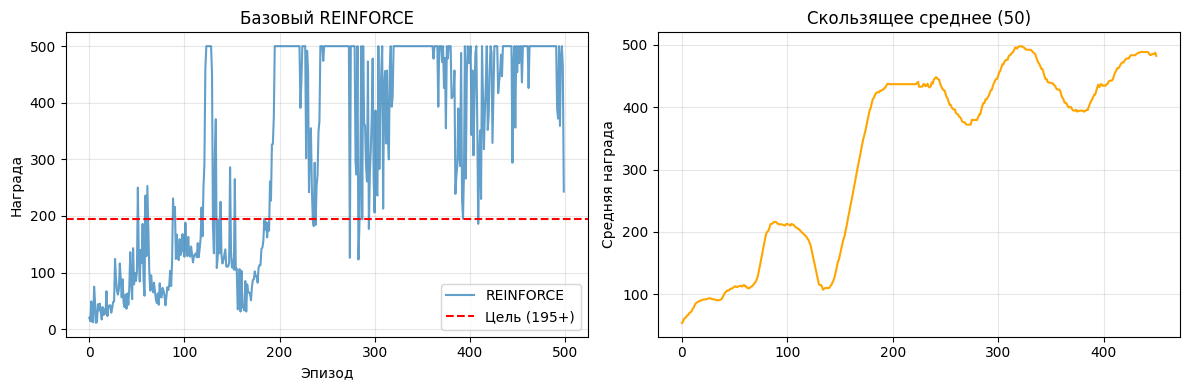

In [2]:
# ===============================================
# 1. БАЗОВЫЙ REINFORCE + ГРАФИК
# ===============================================
class PolicyNetwork(nn.Module):
    """Простая policy сеть для дискретных действий"""
    def __init__(self, n_state, n_action, n_hidden=128):
        super().__init__()
        self.fc1 = nn.Linear(n_state, n_hidden)    # Вход -> скрытый слой
        self.fc2 = nn.Linear(n_hidden, n_action)   # Скрытый -> logits действий

    def forward(self, x):
        x = torch.relu(self.fc1(x))                # ReLU активация
        return torch.softmax(self.fc2(x), dim=-1)  # Вероятности действий

policy = PolicyNetwork(n_state, n_action).to(device)
optimizer = optim.Adam(policy.parameters(), lr=1e-2)

def run_episode(env, policy):
    """Собирает полную траекторию одного эпизода"""
    obs, _ = env.reset()                           # Правильный reset
    log_probs, rewards = [], []
    terminated, truncated = False, False

    while not terminated and not truncated:
        obs_tensor = torch.FloatTensor(obs).unsqueeze(0).to(device)  # Быстрый tensor
        probs = policy(obs_tensor)                         # π(a|s)
        m = Categorical(probs)
        action = m.sample()
        log_probs.append(m.log_prob(action.squeeze()))     # log π(a|s)

        obs, reward, terminated, truncated, _ = env.step(action.item())
        rewards.append(reward)

    return log_probs, rewards

def compute_returns(rewards, gamma=0.99):
    """Дисконтированные возвраты с нормализацией"""
    R = 0
    returns = []
    for r in reversed(rewards):
        R = r + gamma * R
        returns.insert(0, R)
    returns = torch.tensor(returns).float().to(device)
    returns = (returns - returns.mean()) / (returns.std() + 1e-8)  # Стабильность
    return returns

# ОБУЧЕНИЕ БАЗОВОГО REINFORCE
print("\n ОБУЧЕНИЕ БАЗОВОГО REINFORCE")
baseline_rewards = []
for episode in range(500):
    log_probs, rewards = run_episode(env, policy)
    returns = compute_returns(rewards)

    # Policy gradient: ∑ logπ(a|s) * G_t
    policy_loss = 0
    for log_prob, R in zip(log_probs, returns):
        policy_loss -= log_prob * R

    optimizer.zero_grad()
    policy_loss.backward()
    optimizer.step()

    total_reward = sum(rewards)
    baseline_rewards.append(total_reward)

    if episode % 50 == 0:
        avg = np.mean(baseline_rewards[-50:])
        print(f"Эпизод {episode:3d}: награда={total_reward:4.0f}, ср(50)={avg:4.0f}")

# 🖼️ ГРАФИК БАЗОВОГО REINFORCE
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(baseline_rewards, alpha=0.7, label='REINFORCE')
plt.title('Базовый REINFORCE')
plt.ylabel('Награда')
plt.xlabel('Эпизод')
plt.axhline(195, color='r', ls='--', label='Цель (195+)')
plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
smoothed = np.convolve(baseline_rewards, np.ones(50)/50, mode='valid')
plt.plot(smoothed, color='orange')
plt.title('Скользящее среднее (50)')
plt.ylabel('Средняя награда')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



 ОБУЧЕНИЕ REINFORCE + BASELINE
REINFORCE+Baseline [  0]:   24, ср(50):  24
REINFORCE+Baseline [ 50]:   10, ср(50):  14
REINFORCE+Baseline [100]:   10, ср(50):   9
REINFORCE+Baseline [150]:    8, ср(50):   9
REINFORCE+Baseline [200]:   10, ср(50):   9
REINFORCE+Baseline [250]:    9, ср(50):  10
REINFORCE+Baseline [300]:    9, ср(50):   9
REINFORCE+Baseline [350]:    9, ср(50):   9
REINFORCE+Baseline [400]:   10, ср(50):   9
REINFORCE+Baseline [450]:   10, ср(50):   9


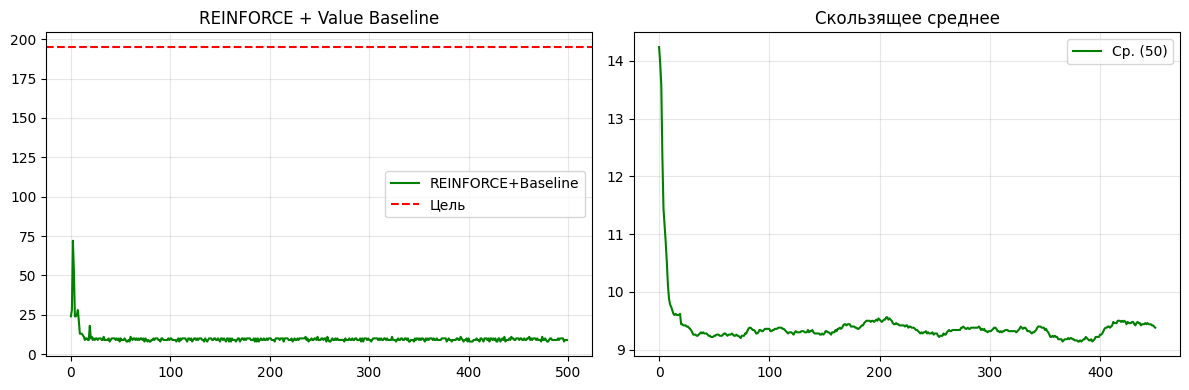

In [3]:
# ===============================================
# 2. REINFORCE с базой (Value Network) + ГРАФИК
# ===============================================
class ValueNetwork(nn.Module):
    """Сеть для оценки ценности состояний (baseline)"""
    def __init__(self, n_state, n_hidden=128):
        super().__init__()
        self.fc1 = nn.Linear(n_state, n_hidden)
        self.fc2 = nn.Linear(n_hidden, 1)
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

# Новые сети для baseline
policy_baseline = PolicyNetwork(n_state, n_action).to(device)
value_net = ValueNetwork(n_state).to(device)
optimizer_policy = optim.Adam(policy_baseline.parameters(), lr=1e-2)
optimizer_value = optim.Adam(value_net.parameters(), lr=1e-2)

reinforce_baseline_rewards = []
print("\n ОБУЧЕНИЕ REINFORCE + BASELINE")
for episode in range(500):
    obs, _ = env.reset()
    log_probs, rewards, states = [], [], []
    terminated, truncated = False, False

    # Собираем траекторию
    while not terminated and not truncated:
        state_tensor = torch.FloatTensor(obs).unsqueeze(0).to(device)
        probs = policy_baseline(state_tensor)
        m = Categorical(probs)
        action = m.sample()

        states.append(state_tensor.detach())           # Состояния для value_net
        log_probs.append(m.log_prob(action.squeeze()))

        obs, reward, terminated, truncated, _ = env.step(action.item())
        rewards.append(reward)

    # Вычисления
    returns = compute_returns(rewards)
    states_tensor = torch.stack(states).squeeze(1)
    baseline = value_net(states_tensor).squeeze()      # V(s) predictions

    # Advantage = G - V(s) → снижает variance!
    advantage = returns - baseline.detach()

    # Policy loss с advantage
    policy_loss = -(torch.stack(log_probs) * advantage).sum()
    optimizer_policy.zero_grad()
    policy_loss.backward()
    optimizer_policy.step()

    # Value loss: обучаем предсказывать returns
    value_loss = nn.MSELoss()(baseline, returns)
    optimizer_value.zero_grad()
    value_loss.backward()
    optimizer_value.step()

    reinforce_baseline_rewards.append(sum(rewards))
    if episode % 50 == 0:
        avg = np.mean(reinforce_baseline_rewards[-50:])
        print(f"REINFORCE+Baseline [{episode:3d}]: {sum(rewards):4.0f}, ср(50):{avg:4.0f}")

#ГРАФИК 2
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(reinforce_baseline_rewards, label='REINFORCE+Baseline', color='green')
plt.title('REINFORCE + Value Baseline')
plt.axhline(195, color='r', ls='--', label='Цель')
plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
smoothed = np.convolve(reinforce_baseline_rewards, np.ones(50)/50, mode='valid')
plt.plot(smoothed, color='green', label='Ср. (50)')
plt.title('Скользящее среднее')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



 ОБУЧЕНИЕ ACTOR-CRITIC (A2C)
A2C [  0]:   59, ср(50):  59
A2C [ 50]:   11, ср(50):  15
A2C [100]:    9, ср(50):  10
A2C [150]:   10, ср(50):   9
A2C [200]:   10, ср(50):   9
A2C [250]:   10, ср(50):   9
A2C [300]:    9, ср(50):   9
A2C [350]:   10, ср(50):   9
A2C [400]:    9, ср(50):   9
A2C [450]:   10, ср(50):   9


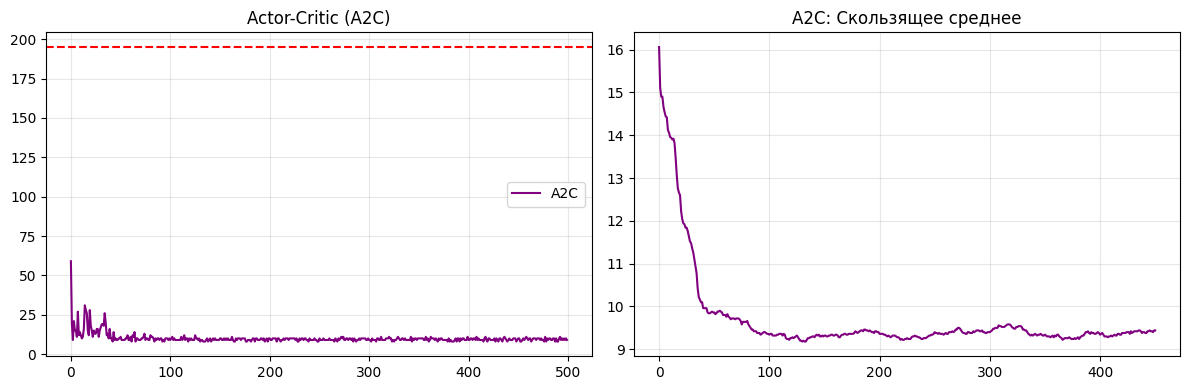

In [4]:
# ===============================================
# 3. Actor-Critic (A2C) + ГРАФИК
# ===============================================
class ActorCritic(nn.Module):
    """Единая Actor+Critic сеть"""
    def __init__(self, n_state, n_action, n_hidden=128):
        super().__init__()
        self.shared = nn.Linear(n_state, n_hidden)     # Общий слой
        self.actor_head = nn.Linear(n_hidden, n_action)  # Actor
        self.critic_head = nn.Linear(n_hidden, 1)      # Critic

    def forward(self, x):
        features = torch.relu(self.shared(x))
        policy = torch.softmax(self.actor_head(features), dim=-1)
        value = self.critic_head(features)
        return policy, value

ac_net = ActorCritic(n_state, n_action).to(device)
ac_optimizer = optim.Adam(ac_net.parameters(), lr=3e-4)  # Меньший lr

print("\n ОБУЧЕНИЕ ACTOR-CRITIC (A2C)")
a2c_rewards = []
for episode in range(500):
    obs, _ = env.reset()
    total_reward = 0
    terminated, truncated = False, False

    while not terminated and not truncated:
        obs_tensor = torch.FloatTensor(obs).unsqueeze(0).to(device)
        probs, value = ac_net(obs_tensor)
        m = Categorical(probs)
        action = m.sample()

        next_obs, reward, terminated, truncated, _ = env.step(action.item())
        total_reward += reward

        # TD target: r + γV(s')*(1-done)
        with torch.no_grad():
            next_tensor = torch.FloatTensor(next_obs).unsqueeze(0).to(device)
            _, next_value = ac_net(next_tensor)
            td_target = reward + 0.99 * next_value.squeeze() * (not (terminated or truncated))

        advantage = td_target - value.squeeze()

        # Actor loss + Critic loss
        actor_loss = -m.log_prob(action.squeeze()) * advantage.detach()
        critic_loss = advantage.pow(2)
        loss = actor_loss + 0.5 * critic_loss  # Баланс actor/critic

        ac_optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(ac_net.parameters(), 0.5)  # Стабильность
        ac_optimizer.step()

        obs = next_obs

    a2c_rewards.append(total_reward)
    if episode % 50 == 0:
        avg = np.mean(a2c_rewards[-50:])
        print(f"A2C [{episode:3d}]: {total_reward:4.0f}, ср(50):{avg:4.0f}")

# ГРАФИК 3
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(a2c_rewards, label='A2C', color='purple')
plt.title('Actor-Critic (A2C)')
plt.axhline(195, color='r', ls='--')
plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
smoothed = np.convolve(a2c_rewards, np.ones(50)/50, mode='valid')
plt.plot(smoothed, color='purple')
plt.title('A2C: Скользящее среднее')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


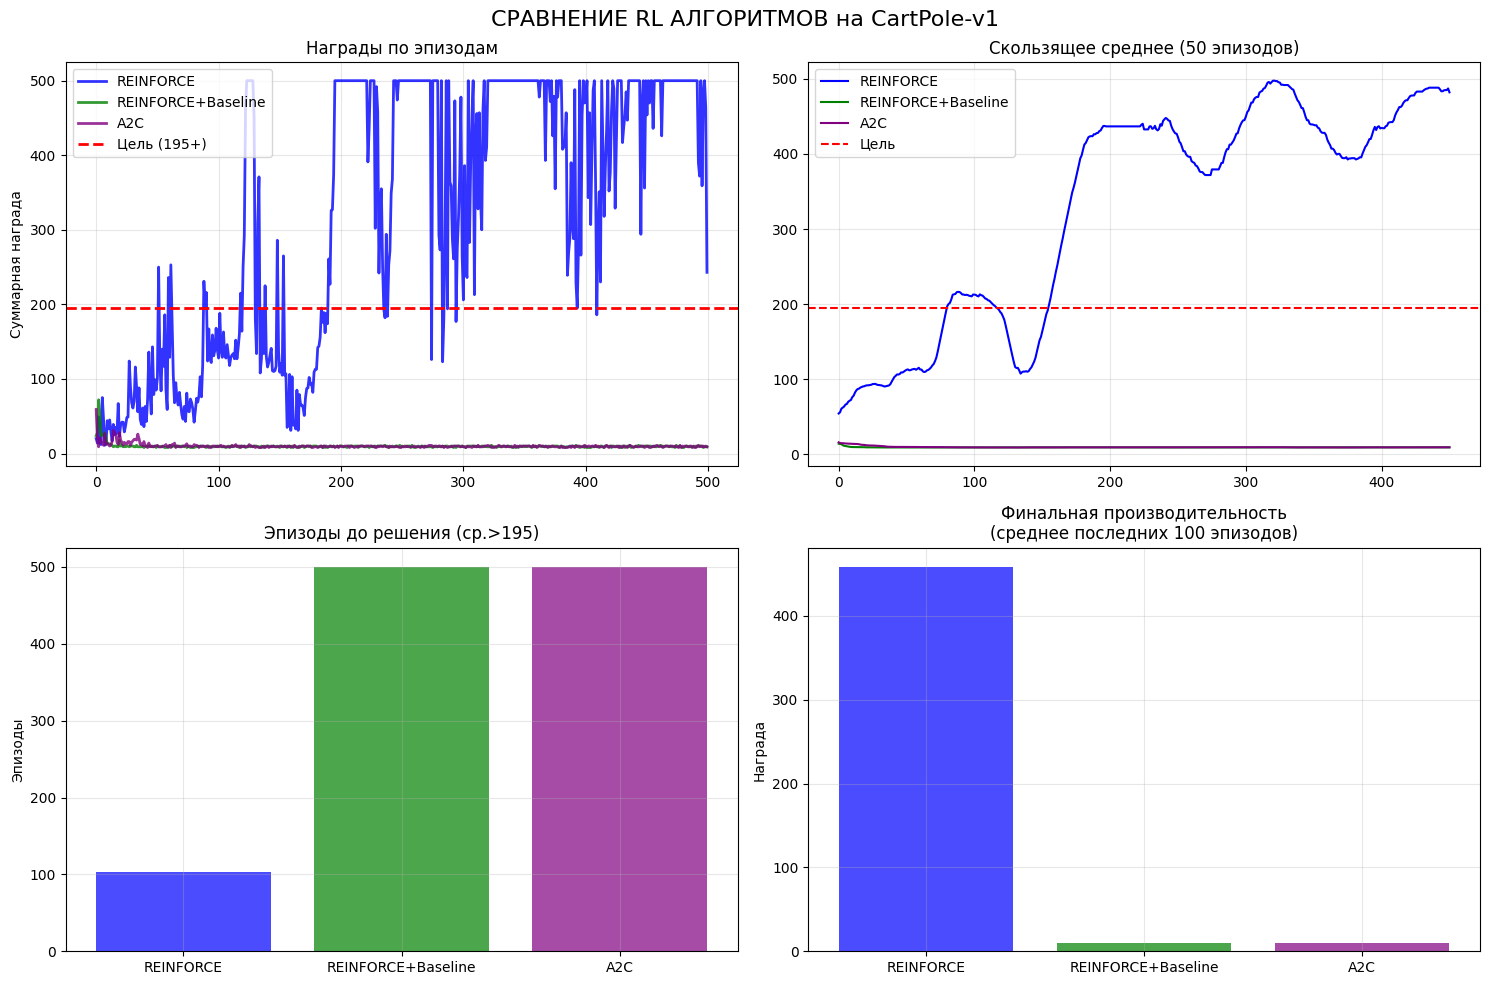


══════════════════════════════════════════════════════════════════════
ИТОГОВАЯ СТАТИСТИКА RL АЛГОРИТМОВ
══════════════════════════════════════════════════════════════════════
 REINFORCE          | Эпизодов до цели: 103 | Финал(100):   458 | Успех: 99.0%
 REINFORCE+Baseline | Эпизодов до цели: 500 | Финал(100):     9 | Успех:  0.0%
 A2C                | Эпизодов до цели: 500 | Финал(100):     9 | Успех:  0.0%

 ЛУЧШИЙ АЛГОРИТМ: REINFORCE
══════════════════════════════════════════════════════════════════════


In [5]:
# ===============================================
# 4. СРАВНЕНИЕ ВСЕХ АЛГОРИТМОВ + СТАТИСТИКА
# ===============================================
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('СРАВНЕНИЕ RL АЛГОРИТМОВ на CartPole-v1', fontsize=16)

methods = {
    'REINFORCE': baseline_rewards,
    'REINFORCE+Baseline': reinforce_baseline_rewards,
    'A2C': a2c_rewards
}
colors = ['blue', 'green', 'purple']

# График 1: Все кривые
ax = axes[0,0]
for i, (name, rewards) in enumerate(methods.items()):
    ax.plot(rewards, label=name, color=colors[i], alpha=0.8, linewidth=2)
ax.axhline(195, color='r', ls='--', lw=2, label='Цель (195+)')
ax.set_title('Награды по эпизодам')
ax.set_ylabel('Суммарная награда')
ax.legend(); ax.grid(True, alpha=0.3)

# График 2: Скользящие средние
ax = axes[0,1]
for i, (name, rewards) in enumerate(methods.items()):
    smoothed = np.convolve(rewards, np.ones(50)/50, mode='valid')
    ax.plot(smoothed, label=name, color=colors[i])
ax.axhline(195, color='r', ls='--', label='Цель')
ax.set_title('Скользящее среднее (50 эпизодов)')
ax.legend(); ax.grid(True, alpha=0.3)

# График 3: Эпизоды до успеха
ax = axes[1,0]
success_episodes = []
for name, rewards in methods.items():
    avg100 = np.convolve(rewards, np.ones(100)/100, mode='valid')
    success_idx = np.where(avg100 > 195)[0]
    episodes = success_idx[0] if len(success_idx) > 0 else 500
    success_episodes.append(episodes)
ax.bar(methods.keys(), success_episodes, color=colors, alpha=0.7)
ax.set_title('Эпизоды до решения (ср.>195)')
ax.set_ylabel('Эпизоды')
ax.grid(True, alpha=0.3)

# График 4: Финальные результаты
ax = axes[1,1]
final_means = [np.mean(r[-100:]) for r in methods.values()]
ax.bar(methods.keys(), final_means, color=colors, alpha=0.7)
ax.set_title('Финальная производительность\n(среднее последних 100 эпизодов)')
ax.set_ylabel('Награда')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 📊 СТАТИСТИКА
print("\n" + "═"*70)
print("ИТОГОВАЯ СТАТИСТИКА RL АЛГОРИТМОВ")
print("═"*70)
for i, (name, rewards) in enumerate(methods.items()):
    final_avg = np.mean(rewards[-100:])
    success_rate = np.mean(np.array(rewards[-100:]) > 195) * 100
    episodes_to_goal = success_episodes[i]
    print(f" {name:18} | Эпизодов до цели: {episodes_to_goal:3d} | "
          f"Финал(100): {final_avg:5.0f} | Успех: {success_rate:4.1f}%")

best_method = max(methods.items(), key=lambda x: np.mean(x[1][-100:]))
print(f"\n ЛУЧШИЙ АЛГОРИТМ: {best_method[0]}")
print("═"*70)

env.close()
